In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

In [17]:
df = pd.read_pickle("housing_cleaned.pkl")
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             21597 non-null  int64         
 1   bedrooms       21597 non-null  float64       
 2   bathrooms      21597 non-null  float64       
 3   sqft_living    21597 non-null  float64       
 4   sqft_lot       21597 non-null  float64       
 5   floors         21597 non-null  float64       
 6   waterfront     21597 non-null  int64         
 7   view           21597 non-null  int64         
 8   condition      21597 non-null  int64         
 9   grade          21597 non-null  int64         
 10  sqft_above     21597 non-null  float64       
 11  sqft_basement  21597 non-null  float64       
 12  yr_built       21597 non-null  int64         
 13  yr_renovated   21597 non-null  int64         
 14  zipcode        21597 non-null  int64         
 15  lat            21597 non-null 

In [4]:
avg_price_by_zip = df.groupby("zipcode")["price"].mean().sort_values()
avg_price_by_zip.info()

<class 'pandas.Series'>
Index: 70 entries, 98002 to 98039
Series name: price
Non-Null Count  Dtype  
--------------  -----  
70 non-null     float64
dtypes: float64(1)
memory usage: 1.1 KB


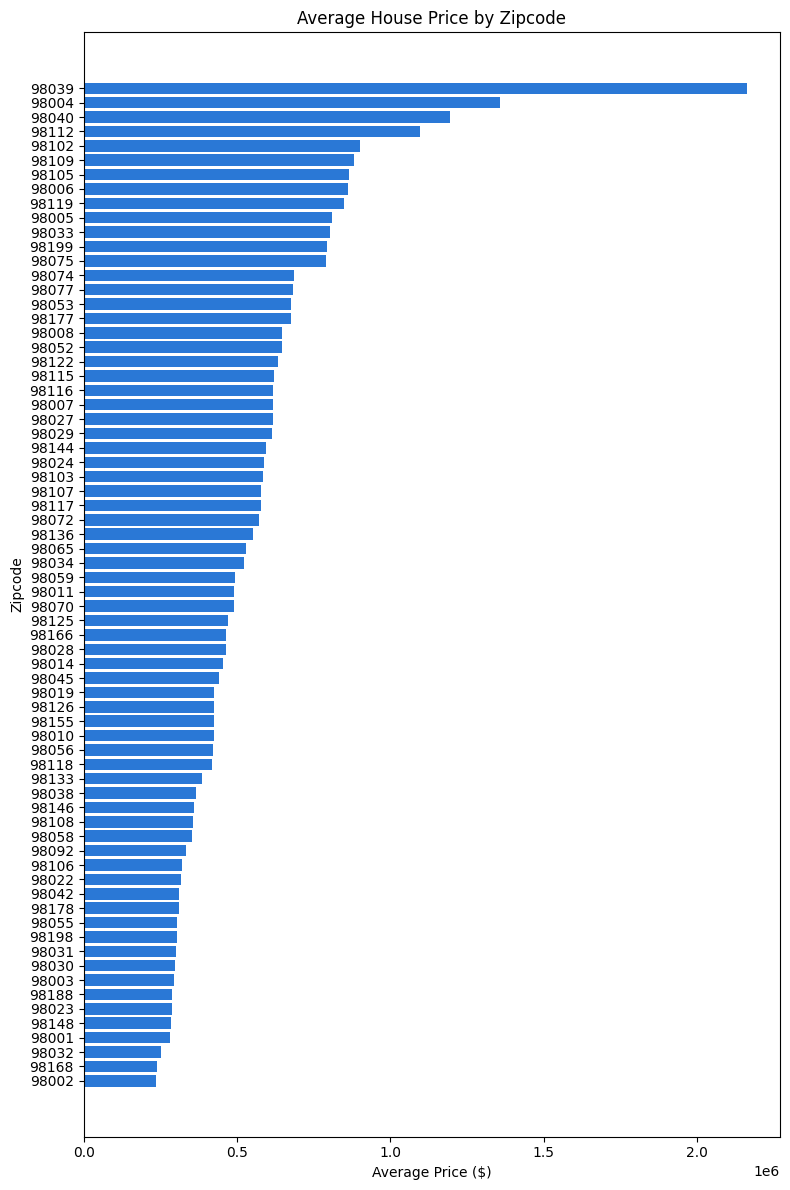

In [5]:
fig, ax = plt.subplots(figsize=(8, 12))
ax.barh(avg_price_by_zip.index.astype(str), avg_price_by_zip.values, color="#2a78d6")
ax.set_xlabel("Average Price ($)")
ax.set_ylabel("Zipcode")
ax.set_title("Average House Price by Zipcode")
plt.tight_layout()
plt.show()


In [6]:
lower_cutoff = avg_price_by_zip.quantile(0.33)
upper_cutoff = avg_price_by_zip.quantile(0.67)

middle_class_zips = avg_price_by_zip[(avg_price_by_zip >= lower_cutoff) & (avg_price_by_zip <= upper_cutoff)]
print(middle_class_zips)

zipcode
98056    420895.475369
98010    423665.990000
98155    423736.905830
98126    424734.604520
98019    424815.063158
98045    440232.313636
98014    455617.112903
98028    462488.869258
98166    464322.389764
98125    469928.767726
98070    489382.017094
98011    490377.107692
98059    493625.309829
98034    521740.014679
98065    529629.782468
98136    551768.520913
98072    570073.520147
98117    576834.808318
98107    579109.808271
98103    585048.779070
98024    586120.875000
98144    594706.542274
98029    612642.738318
98027    617053.966019
Name: price, dtype: float64


In [7]:
middle_class_zip_list = middle_class_zips.index.tolist()
df_middle_class_zip = df[df["zipcode"].isin(middle_class_zip_list)].reset_index(drop=True)
df_middle_class_zip.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,6414100192,3.0,2.25,2570.0,7242.0,2.0,0,0,3,7,...,400.0,1951,1991,98125,47.7210,-122.319,1690.0,7639.0,2014-12-09,538000.0
1,5631500400,2.0,1.00,770.0,10000.0,1.0,0,0,3,6,...,0.0,1933,0,98028,47.7379,-122.233,2720.0,8062.0,2015-02-25,180000.0
2,2487200875,4.0,3.00,1960.0,5000.0,1.0,0,0,5,7,...,910.0,1965,0,98136,47.5208,-122.393,1360.0,5000.0,2014-12-09,604000.0
3,114101516,3.0,1.00,1430.0,19901.0,1.5,0,0,4,7,...,0.0,1927,0,98028,47.7558,-122.229,1780.0,12697.0,2014-05-28,310000.0
4,1175000570,5.0,2.00,1810.0,4850.0,1.5,0,0,3,7,...,0.0,1900,0,98107,47.6700,-122.394,1360.0,4850.0,2015-03-12,530000.0


In [22]:
def tier_from_avg_price(avg_price):
    if avg_price < lower_cutoff:
        return 'bottom'
    elif avg_price <= upper_cutoff:
        return 'middle'
    else:
        return 'top'

zip_tier_map = avg_price_by_zip.apply(tier_from_avg_price)
df['zip_tier'] = df['zipcode'].map(zip_tier_map)

df['price_per_sqft'] = df['price'] / df['sqft_living']

tier_summary = df.groupby('zip_tier').agg(
    avg_sqft=('sqft_living', 'mean'),
    avg_price_per_sqft=('price_per_sqft', 'mean'),
    n=('price', 'count')
)
print(tier_summary)


             avg_sqft  avg_price_per_sqft     n
zip_tier                                       
bottom    1842.798731          185.903600  7249
middle    2000.875996          273.112621  7532
top       2420.725499          337.442029  6816


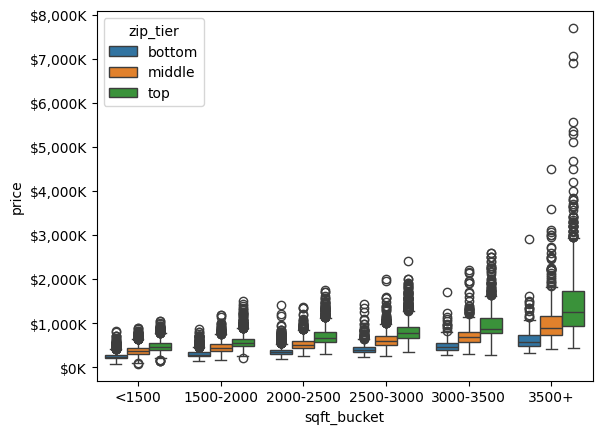

In [27]:
ax = sns.boxplot(data=df, x='sqft_bucket', y='price', hue='zip_tier')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x/1000:,.0f}K'))

plt.show()


### Hypothesis 3: Location Premium in House Prices

**Hypothesis:** House prices differ significantly by location (zipcode), and this difference holds independent of house size or features — meaning there is a location premium baked into prices, which can be used to identify middle-class neighborhoods.

**Method:**
Zipcodes were split into three tiers (bottom/middle/top) based on their average house price, using the 33rd and 67th percentile cutoffs across all zipcode averages. This tiering was then applied at the house level to compare outcomes across groups.

**Findings:**

1. **Size vs. price/sqft by tier** — average house size was comparable across tiers (bottom: 1843 sqft, middle: 2000 sqft, top: 2420 sqft), while average price per square foot differed clearly (bottom: $185/sqft, middle: $273/sqft, top: $337/sqft). Because size stayed roughly flat while price/sqft moved, the price gap between tiers isn't explained by houses simply being bigger or smaller — it's a per-square-foot premium tied to the zipcode itself.

2. **Same-size comparison** — bucketing houses by sqft range and comparing price across tiers within each bucket showed [describe what you saw, e.g. "top-tier zipcodes priced noticeably higher than middle and bottom tiers at every sqft bucket, with the gap widening in larger homes"]. This directly controls for size and shows the tier-based price difference persists even when comparing similarly-sized homes.

**Conclusion:**
Both analyses support the hypothesis: location (zipcode) carries a price premium that isn't simply a proxy for house size. This validates the tercile-based method (33rd–67th percentile of average zipcode price) as a reasonable way to identify "middle-class" neighborhoods for this dataset — the middle-tier zipcodes are meaningfully distinct from the bottom and top tiers on a size-adjusted basis, not just on raw average price.